
# NB-04 · Bootstrap Your Own Latent (BYOL) + DeepLabV3-ResNet50  
## Brain Tumour MRI Binary Semantic Segmentation from COCO Polygons

**Course:** CSE 438: Digital Image Processing  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

### Learning objective

This notebook studies label-free representation learning followed by supervised semantic segmentation:

1. **BYOL pretraining:** a ResNet-50 online encoder learns MRI representations by predicting the target-network representation of another augmented view of the same image.
2. **DeepLabV3 fine-tuning:** the trained BYOL online encoder is transferred directly into the ResNet-50 backbone of DeepLabV3 for tumour-region segmentation.

The COCO polygon annotations are merged into binary semantic masks:

\[
0=\text{background}, \qquad 1=\text{tumour region}.
\]

### Why BYOL is suitable for this classroom experiment

BYOL does not maintain a negative queue and does not require explicit negative image pairs. Its online network includes an additional predictor, while the target network is updated through an exponential moving average of the online network. Students can therefore compare a non-contrastive self-supervised pipeline against contrastive approaches such as SimCLR and MoCo.

### Kaggle execution safety

The notebook uses standard contiguous tensors only. CUDA is selected only after an actual kernel-and-backward test succeeds. AMP is enabled only for functional CUDA execution. The BYOL regression objective is evaluated in `float32` to retain stable cosine-distance calculations.



## Pipeline summary

\[
\text{unlabelled MRI}
\rightarrow
\left\{
\begin{array}{l}
\text{view 1} \rightarrow \text{online encoder} \rightarrow \text{projector} \rightarrow \text{predictor} \\
\text{view 2} \rightarrow \text{target encoder} \rightarrow \text{projector}
\end{array}
\right.
\rightarrow
\text{BYOL regression loss}
\]

The two views are exchanged to form a symmetric loss. After self-supervised learning, only the **online ResNet-50 encoder** is transferred into DeepLabV3:

\[
\text{BYOL online ResNet-50}
\rightarrow
\text{DeepLabV3-ResNet50 backbone}
\rightarrow
\text{binary tumour mask}.
\]


In [1]:

# ============================================================
# 1. Imports, paths, experiment configuration, and reproducibility
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import copy
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image, ImageDraw

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.segmentation import deeplabv3_resnet50

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# Required dataset path for this CSE 438 experiment.
# ------------------------------------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

# ------------------------------------------------------------
# All results are saved within Kaggle's writable working area.
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/byol_deeplabv3_brain_tumour")
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRIC_DIR = OUTPUT_DIR / "metrics"

for directory in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, METRIC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Core configuration.
# ------------------------------------------------------------
SEED = 438
IMAGE_SIZE = 224
NUM_CLASSES = 2
BYOL_EPOCHS = 10
SEGMENTATION_EPOCHS = 10
NUM_WORKERS = 2

PROJECTION_DIM = 256
PROJECTOR_HIDDEN_DIM = 2048
PREDICTOR_HIDDEN_DIM = 512
EMA_BASE_MOMENTUM = 0.996
BYOL_LR = 3e-4
SEGMENTATION_LR = 2e-4
WEIGHT_DECAY = 1e-4

# Set True only when a supervised ImageNet starting point is intentionally
# desired for a comparison. False keeps BYOL as the representation-learning start.
USE_IMAGENET_INITIALISATION = False

def seed_everything(seed: int = SEED) -> None:
    """Set seeds for reproducible data ordering, augmentation choices, and parameters."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass

seed_everything()

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")


Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
Output directory: /kaggle/working/byol_deeplabv3_brain_tumour


In [2]:

# ============================================================
# 2. CUDA compatibility probe and conditional AMP support
# ============================================================

def choose_safe_device():
    """
    CUDA may be visible in a Kaggle session even when the installed PyTorch
    build cannot execute kernels on the exposed device. Run an actual
    convolution and backward pass before selecting GPU execution.
    """
    if not torch.cuda.is_available():
        print("CUDA is unavailable. CPU mode selected; AMP is disabled.")
        return torch.device("cpu"), False

    try:
        probe_input = torch.randn(2, 3, 24, 24, device="cuda", requires_grad=True)
        probe_layer = nn.Conv2d(3, 4, kernel_size=3, padding=1).to("cuda")
        probe_loss = probe_layer(probe_input).square().mean()
        probe_loss.backward()
        torch.cuda.synchronize()

        print(f"CUDA kernel probe succeeded on: {torch.cuda.get_device_name(0)}")
        print("AMP is enabled for compatible CUDA forward passes.")
        return torch.device("cuda"), True
    except Exception as error:
        print("CUDA was detected, but executable kernel validation failed.")
        print(f"Diagnostic: {type(error).__name__}: {error}")
        print("CPU fallback selected; AMP is disabled.")
        return torch.device("cpu"), False

DEVICE, AMP_ENABLED = choose_safe_device()

def autocast_context():
    """Activate autocast only after the CUDA probe has succeeded."""
    if not AMP_ENABLED:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
    except AttributeError:
        return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)

def disable_autocast_for_byol(tensor):
    """Perform normalisation and cosine-distance loss calculation in float32."""
    if not tensor.is_cuda:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", enabled=False)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=False)

def create_grad_scaler():
    """Support the AMP interfaces commonly available in Kaggle PyTorch images."""
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

BYOL_BATCH_SIZE = 24 if DEVICE.type == "cuda" else 4
SEGMENTATION_BATCH_SIZE = 6 if DEVICE.type == "cuda" else 2
PIN_MEMORY = DEVICE.type == "cuda"

print(f"Selected device: {DEVICE}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"BYOL batch size: {BYOL_BATCH_SIZE}; segmentation batch size: {SEGMENTATION_BATCH_SIZE}")


CUDA kernel probe succeeded on: Tesla T4
AMP is enabled for compatible CUDA forward passes.
Selected device: cuda
AMP enabled: True
BYOL batch size: 24; segmentation batch size: 6



## COCO polygons to binary masks

The annotation file associates each image with polygon coordinates. Since this task is binary semantic segmentation, all polygon instances associated with one MRI are filled into one class-index mask. A pixel receives value `1` whenever it lies in any tumour polygon; all remaining pixels receive value `0`.


In [3]:

# ============================================================
# 3. COCO loading, polygon rasterisation, and dataset classes
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
NORMALISE = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def read_coco_records(split_directory: Path):
    """Load readable image entries and index all polygon annotations by image id."""
    annotation_file = split_directory / "_annotations.coco.json"
    if not annotation_file.exists():
        raise FileNotFoundError(f"COCO annotation file not found: {annotation_file}")

    with open(annotation_file, "r", encoding="utf-8") as file:
        coco = json.load(file)

    annotations_by_image = {}
    for annotation in coco.get("annotations", []):
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    records = []
    for image_info in coco.get("images", []):
        image_path = split_directory / image_info["file_name"]
        if not image_path.exists():
            fallback_path = split_directory / Path(image_info["file_name"]).name
            image_path = fallback_path if fallback_path.exists() else image_path

        if image_path.exists():
            records.append({
                "image_id": image_info["id"],
                "image_path": image_path,
                "file_name": image_info["file_name"],
                "annotations": annotations_by_image.get(image_info["id"], []),
            })

    if not records:
        raise RuntimeError(f"No readable images were indexed from: {split_directory}")
    return records

def polygons_to_binary_mask(image_size, annotations):
    """Fill every COCO polygon for one MRI into a single 0/1 semantic mask."""
    mask = Image.new("L", image_size, color=0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        segmentation = annotation.get("segmentation", [])
        if not isinstance(segmentation, list):
            raise ValueError("This notebook expects COCO polygon segmentation rather than RLE.")

        for polygon in segmentation:
            if len(polygon) < 6:
                continue
            points = [
                (float(polygon[index]), float(polygon[index + 1]))
                for index in range(0, len(polygon) - 1, 2)
            ]
            drawer.polygon(points, outline=1, fill=1)

    return mask

class PairedSegmentationTransform:
    """
    Spatial operations are synchronised between image and mask. Nearest-neighbour
    mask resizing preserves the class labels 0 and 1.
    """
    def __init__(self, training=False, size=IMAGE_SIZE):
        self.training = training
        self.size = size

    def __call__(self, image, mask):
        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.20:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

        image = TF.resize(image, [self.size, self.size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size], interpolation=InterpolationMode.NEAREST)

        image_tensor = NORMALISE(TF.to_tensor(image)).contiguous()
        mask_array = np.asarray(mask, dtype=np.int64).copy()
        mask_tensor = torch.from_numpy((mask_array > 0).astype(np.int64)).long().contiguous()
        return image_tensor, mask_tensor

class COCOSemanticMaskDataset(Dataset):
    """Return normalised MRI images and merged binary tumour masks."""
    def __init__(self, split_directory, training=False):
        self.records = read_coco_records(Path(split_directory))
        self.transform = PairedSegmentationTransform(training=training)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["image_path"]).convert("RGB")
        mask = polygons_to_binary_mask(image.size, record["annotations"])
        image_tensor, mask_tensor = self.transform(image, mask)
        return image_tensor, mask_tensor, record["file_name"]

# BYOL creates two correlated transformations from the same unlabelled MRI.
BYOL_AUGMENTATION = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.50, 1.0), interpolation=InterpolationMode.BILINEAR),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(brightness=0.25, contrast=0.25)], p=0.75),
    T.RandomGrayscale(p=0.15),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.35),
    T.ToTensor(),
    NORMALISE,
])

class BYOLTwoViewDataset(Dataset):
    """Self-supervised dataset: annotations are not required during BYOL pretraining."""
    def __init__(self, split_directory):
        self.records = read_coco_records(Path(split_directory))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image = Image.open(self.records[index]["image_path"]).convert("RGB")
        online_view = BYOL_AUGMENTATION(image).contiguous()
        target_view = BYOL_AUGMENTATION(image).contiguous()
        return online_view, target_view


In [4]:

# ============================================================
# 4. Build DataLoaders and measure foreground-mask distribution
# ============================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found at {DATA_ROOT}. Add the specified dataset to the Kaggle notebook."
    )

TRAIN_DIR = DATA_ROOT / "train"
VALID_DIR = DATA_ROOT / "valid"
TEST_DIR = DATA_ROOT / "test"

train_dataset = COCOSemanticMaskDataset(TRAIN_DIR, training=True)
train_display_dataset = COCOSemanticMaskDataset(TRAIN_DIR, training=False)
valid_dataset = COCOSemanticMaskDataset(VALID_DIR, training=False)
test_dataset = COCOSemanticMaskDataset(TEST_DIR, training=False)
byol_dataset = BYOLTwoViewDataset(TRAIN_DIR)

loader_options = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(
    train_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=True,
    drop_last=False, **loader_options
)
valid_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_options
)
test_loader = DataLoader(
    test_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_options
)
feature_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_options
)

# BYOL heads contain BatchNorm. drop_last=True prevents a final one-image batch.
byol_loader = DataLoader(
    byol_dataset, batch_size=BYOL_BATCH_SIZE, shuffle=True,
    drop_last=True, **loader_options
)

if len(byol_loader) == 0:
    raise RuntimeError("BYOL DataLoader is empty. Reduce BYOL_BATCH_SIZE while retaining drop_last=True.")

print(f"Training MRIs:   {len(train_dataset)}")
print(f"Validation MRIs: {len(valid_dataset)}")
print(f"Test MRIs:       {len(test_dataset)}")
print(f"BYOL batches per epoch: {len(byol_loader)}")

def summarise_masks(dataset, split_name):
    foreground_pixels = 0
    foreground_images = 0
    all_pixels = 0

    for _, mask, _ in tqdm(dataset, desc=f"Inspecting {split_name} masks", leave=False):
        count = int(mask.sum().item())
        foreground_pixels += count
        foreground_images += int(count > 0)
        all_pixels += int(mask.numel())

    return {
        "split": split_name,
        "images": len(dataset),
        "images_with_tumour": foreground_images,
        "tumour_image_percentage": 100.0 * foreground_images / max(1, len(dataset)),
        "foreground_pixel_percentage": 100.0 * foreground_pixels / max(1, all_pixels),
    }

mask_summary = pd.DataFrame([
    summarise_masks(train_display_dataset, "train"),
    summarise_masks(valid_dataset, "valid"),
    summarise_masks(test_dataset, "test"),
])
mask_summary.to_csv(METRIC_DIR / "mask_distribution.csv", index=False)
mask_summary


Training MRIs:   1502
Validation MRIs: 429
Test MRIs:       215
BYOL batches per epoch: 62


Inspecting train masks:   0%|          | 0/1502 [00:00<?, ?it/s]

Inspecting valid masks:   0%|          | 0/429 [00:00<?, ?it/s]

Inspecting test masks:   0%|          | 0/215 [00:00<?, ?it/s]

,split,images,images_with_tumour,tumour_image_percentage,foreground_pixel_percentage
0,train,1502,1501,99.933422,3.710254
1,valid,429,429,100.000000,3.721827
2,test,215,215,100.000000,3.716379


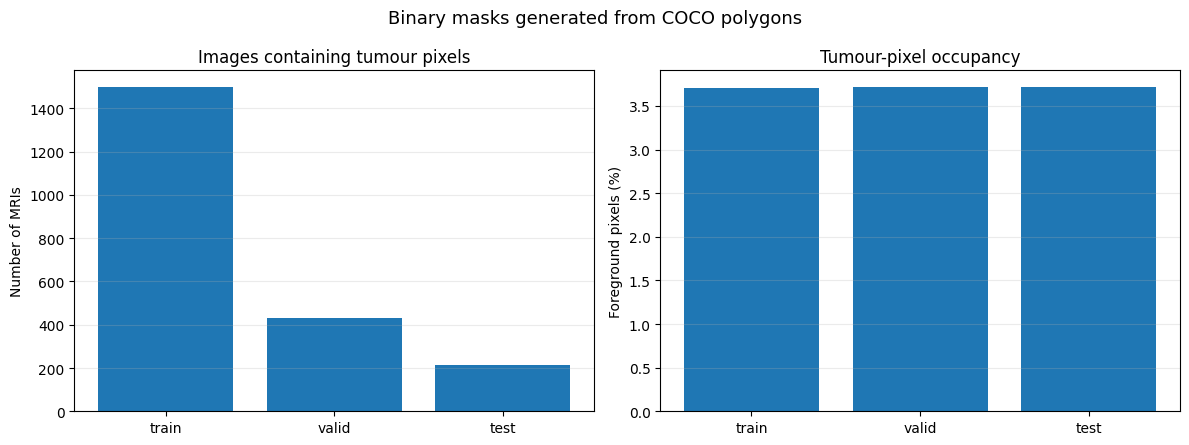

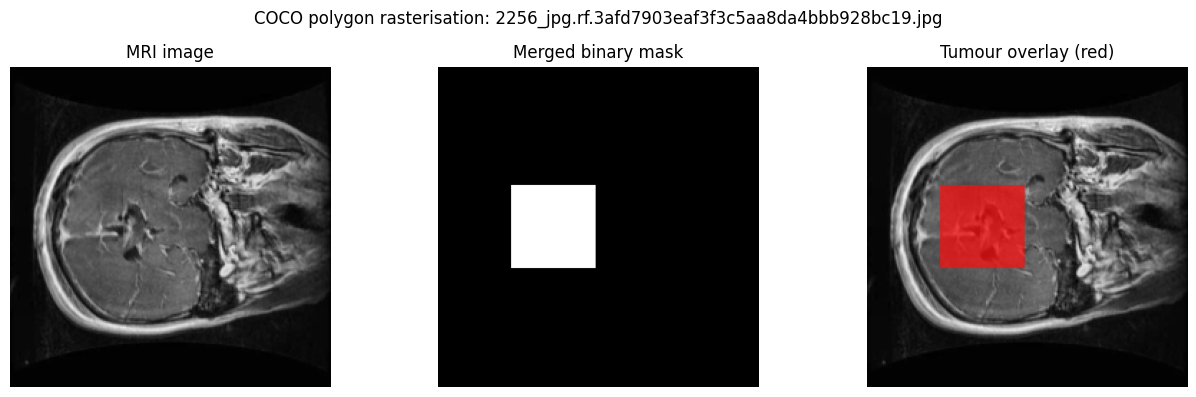

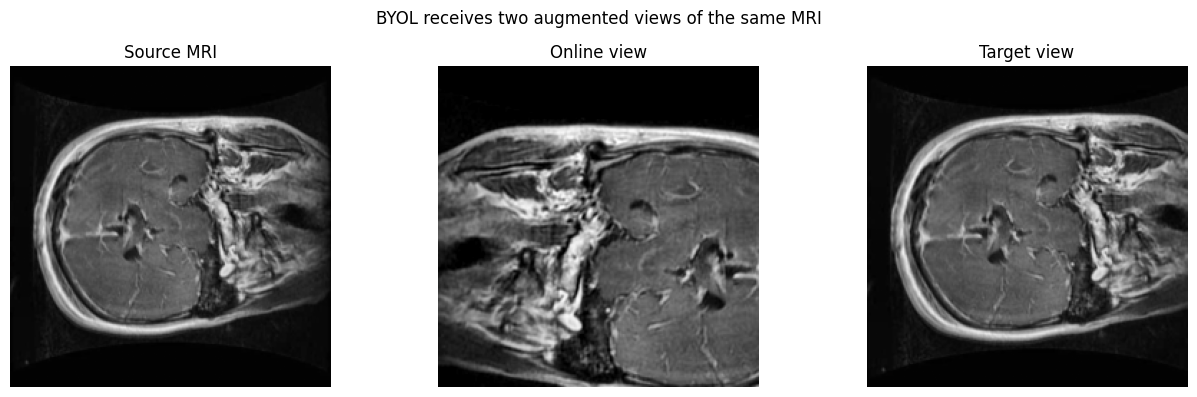

In [5]:

# ============================================================
# 5. Dataset interpretation: mask overlays and paired BYOL views
# ============================================================

def undo_normalisation(tensor):
    """Convert a model tensor back into a displayable RGB image."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def make_mask_overlay(image_array, mask_array, colour=(1.0, 0.05, 0.05), alpha=0.72):
    """Highlight only foreground pixels with a clearly visible overlay colour."""
    overlay = image_array.copy()
    region = np.asarray(mask_array).astype(bool)
    if region.any():
        colour_array = np.asarray(colour, dtype=np.float32)
        overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour_array
    return np.clip(overlay, 0.0, 1.0)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(mask_summary["split"], mask_summary["images_with_tumour"])
axes[0].set_title("Images containing tumour pixels")
axes[0].set_ylabel("Number of MRIs")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(mask_summary["split"], mask_summary["foreground_pixel_percentage"])
axes[1].set_title("Tumour-pixel occupancy")
axes[1].set_ylabel("Foreground pixels (%)")
axes[1].grid(axis="y", alpha=0.25)

figure.suptitle("Binary masks generated from COCO polygons", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "01_mask_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

positive_index = next(
    (index for index in range(len(train_display_dataset))
     if train_display_dataset[index][1].sum().item() > 0),
    0,
)
sample_image, sample_mask, sample_name = train_display_dataset[positive_index]
image_array = undo_normalisation(sample_image)
mask_array = sample_mask.numpy()
ground_truth_overlay = make_mask_overlay(image_array, mask_array)

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(image_array)
axes[0].set_title("MRI image")
axes[1].imshow(mask_array, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Merged binary mask")
axes[2].imshow(ground_truth_overlay)
axes[2].set_title("Tumour overlay (red)")
for axis in axes:
    axis.axis("off")
figure.suptitle(f"COCO polygon rasterisation: {sample_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "02_polygon_mask_overlay.png", dpi=180, bbox_inches="tight")
plt.show()

first_view, second_view = byol_dataset[positive_index]
figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(image_array)
axes[0].set_title("Source MRI")
axes[1].imshow(undo_normalisation(first_view))
axes[1].set_title("Online view")
axes[2].imshow(undo_normalisation(second_view))
axes[2].set_title("Target view")
for axis in axes:
    axis.axis("off")
figure.suptitle("BYOL receives two augmented views of the same MRI", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "03_byol_two_views.png", dpi=180, bbox_inches="tight")
plt.show()


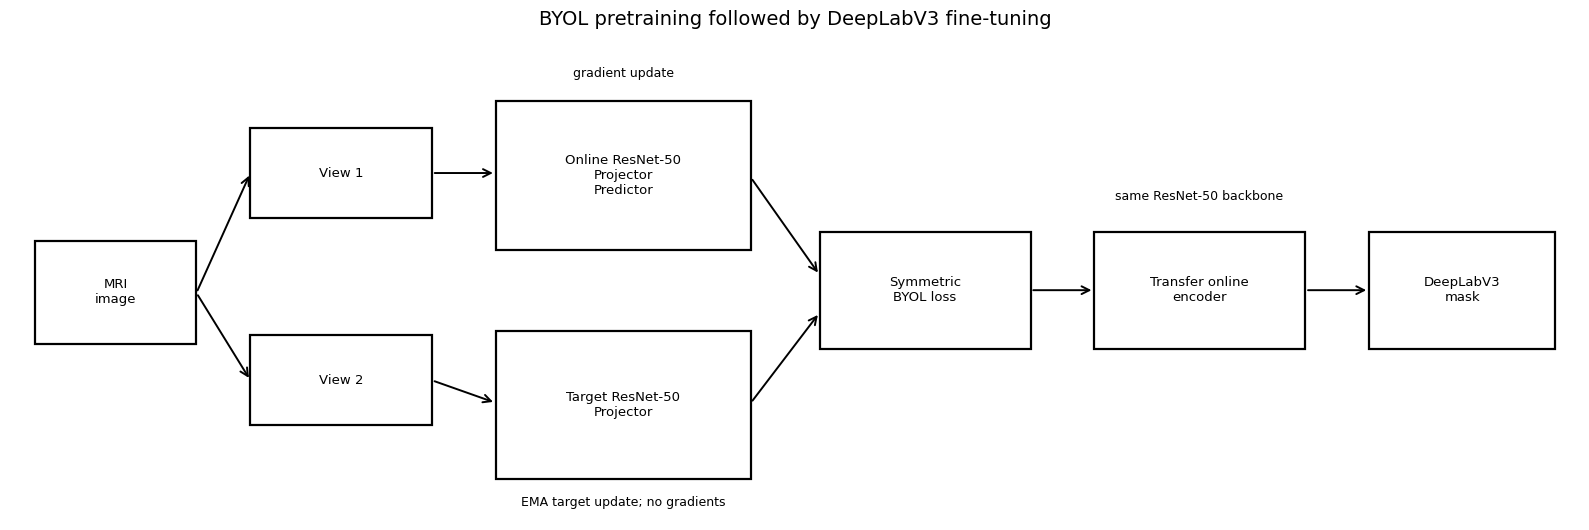

In [6]:

# ============================================================
# 6. Instructional diagram: BYOL representation transfer to DeepLabV3
# ============================================================

figure, axis = plt.subplots(figsize=(16, 5.4))
axis.set_xlim(0, 16)
axis.set_ylim(0, 5.4)
axis.axis("off")

boxes = [
    (0.25, 1.95, 1.65, 1.15, "MRI\nimage"),
    (2.45, 3.35, 1.85, 1.0, "View 1"),
    (2.45, 1.05, 1.85, 1.0, "View 2"),
    (4.95, 3.0, 2.6, 1.65, "Online ResNet-50\nProjector\nPredictor"),
    (4.95, 0.45, 2.6, 1.65, "Target ResNet-50\nProjector"),
    (8.25, 1.9, 2.15, 1.3, "Symmetric\nBYOL loss"),
    (11.05, 1.9, 2.15, 1.3, "Transfer online\nencoder"),
    (13.85, 1.9, 1.9, 1.3, "DeepLabV3\nmask"),
]

for x, y, width, height, label in boxes:
    axis.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=1.6))
    axis.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=9.5)

arrows = [
    ((1.90, 2.52), (2.45, 3.85)),
    ((1.90, 2.52), (2.45, 1.55)),
    ((4.30, 3.85), (4.95, 3.85)),
    ((4.30, 1.55), (4.95, 1.30)),
    ((7.55, 3.80), (8.25, 2.72)),
    ((7.55, 1.30), (8.25, 2.30)),
    ((10.40, 2.55), (11.05, 2.55)),
    ((13.20, 2.55), (13.85, 2.55)),
]

for start, finish in arrows:
    axis.add_patch(FancyArrowPatch(start, finish, arrowstyle="->", mutation_scale=14, linewidth=1.4))

axis.text(6.25, 4.92, "gradient update", ha="center", fontsize=9)
axis.text(6.25, 0.16, "EMA target update; no gradients", ha="center", fontsize=9)
axis.text(12.12, 3.55, "same ResNet-50 backbone", ha="center", fontsize=9)

axis.set_title("BYOL pretraining followed by DeepLabV3 fine-tuning", fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "04_byol_deeplabv3_workflow.png", dpi=180, bbox_inches="tight")
plt.show()



## BYOL architecture

For augmented views \(v_1\) and \(v_2\), the online branch produces predictions \(p_1\) and \(p_2\). The target branch produces projections \(z_1\) and \(z_2\), detached from gradient computation. The symmetric BYOL loss is:

\[
\mathcal{L}_{\mathrm{BYOL}}
=
\frac{1}{2}
\left[
\left(2-2 \cdot \frac{p_1^\top z_2}{\|p_1\|_2\|z_2\|_2}\right)
+
\left(2-2 \cdot \frac{p_2^\top z_1}{\|p_2\|_2\|z_1\|_2}\right)
\right].
\]

The target network is updated after each optimiser step using exponential moving average:

\[
\xi \leftarrow \tau\xi +(1-\tau)\theta ,
\]

where \(\theta\) denotes online parameters, \(\xi\) denotes target parameters, and \(\tau\) approaches \(1\) during training.


In [7]:

# ============================================================
# 7. ResNet-50 BYOL architecture with float32 regression loss
# ============================================================

def build_resnet_encoder(use_imagenet=False):
    """Build a ResNet-50 representation encoder without its classification layer."""
    if use_imagenet:
        try:
            encoder = resnet50(weights=ResNet50_Weights.DEFAULT)
            print("ResNet-50 initialised with ImageNet weights.")
        except Exception as error:
            print(f"ImageNet weights were unavailable ({error}); using random initialisation.")
            encoder = resnet50(weights=None)
    else:
        encoder = resnet50(weights=None)

    encoder.fc = nn.Identity()
    return encoder

class BYOLProjector(nn.Module):
    """Projection network mapping pooled ResNet features into the BYOL latent space."""
    def __init__(self, input_dim=2048, hidden_dim=PROJECTOR_HIDDEN_DIM, output_dim=PROJECTION_DIM):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim, bias=False),
            nn.BatchNorm1d(output_dim, affine=False),
        )

    def forward(self, x):
        return self.network(x)

class BYOLPredictor(nn.Module):
    """Prediction head existing only in the online pathway."""
    def __init__(self, input_dim=PROJECTION_DIM, hidden_dim=PREDICTOR_HIDDEN_DIM):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        return self.network(x)

class BYOL(nn.Module):
    """
    BYOL model with online and exponential-moving-average target branches.
    The target branch is evaluated without gradients; its states are updated
    after each online optimiser step.
    """
    def __init__(self, use_imagenet=False):
        super().__init__()

        self.online_encoder = build_resnet_encoder(use_imagenet)
        self.online_projector = BYOLProjector()
        self.online_predictor = BYOLPredictor()

        self.target_encoder = copy.deepcopy(self.online_encoder)
        self.target_projector = copy.deepcopy(self.online_projector)

        for parameter in list(self.target_encoder.parameters()) + list(self.target_projector.parameters()):
            parameter.requires_grad = False

    def online_forward(self, image):
        representation = self.online_encoder(image)
        projection = self.online_projector(representation)
        return self.online_predictor(projection)

    @torch.no_grad()
    def target_forward(self, image):
        projection = self.target_projector(self.target_encoder(image))
        return projection.detach()

    @torch.no_grad()
    def update_target(self, momentum):
        """Update parameters and BatchNorm buffers through exponential moving average."""
        online_modules = [self.online_encoder, self.online_projector]
        target_modules = [self.target_encoder, self.target_projector]

        for online_module, target_module in zip(online_modules, target_modules):
            for online_parameter, target_parameter in zip(
                online_module.parameters(), target_module.parameters()
            ):
                target_parameter.data.mul_(momentum).add_(
                    online_parameter.data, alpha=1.0 - momentum
                )

            # Floating running statistics are also tracked by EMA; integer batch
            # counters are copied directly.
            for online_buffer, target_buffer in zip(
                online_module.buffers(), target_module.buffers()
            ):
                if torch.is_floating_point(target_buffer):
                    target_buffer.data.mul_(momentum).add_(
                        online_buffer.data, alpha=1.0 - momentum
                    )
                else:
                    target_buffer.data.copy_(online_buffer.data)

def byol_pair_loss(online_prediction, target_projection):
    """
    Negative cosine-similarity regression in explicit float32. This avoids
    precision loss when AMP is active during encoder and MLP forward passes.
    """
    with disable_autocast_for_byol(online_prediction):
        prediction = F.normalize(online_prediction.float(), dim=1)
        target = F.normalize(target_projection.detach().float(), dim=1)
        cosine_similarity = (prediction * target).sum(dim=1)
        loss = (2.0 - 2.0 * cosine_similarity).mean()
    return loss, cosine_similarity.detach()

def byol_symmetric_loss(model, first_view, second_view):
    """Exchange online and target views and average the two regression losses."""
    with autocast_context():
        prediction_one = model.online_forward(first_view)
        prediction_two = model.online_forward(second_view)

        with torch.no_grad():
            target_one = model.target_forward(first_view)
            target_two = model.target_forward(second_view)

    loss_one, similarity_one = byol_pair_loss(prediction_one, target_two)
    loss_two, similarity_two = byol_pair_loss(prediction_two, target_one)
    loss = 0.5 * (loss_one + loss_two)
    similarities = torch.cat([similarity_one, similarity_two], dim=0)

    # Mean standard deviation across feature dimensions is recorded as a simple
    # collapse-monitoring diagnostic for classroom interpretation.
    with torch.no_grad():
        latent = F.normalize(target_two.float(), dim=1)
        feature_std = latent.std(dim=0).mean()
    return loss, similarities, feature_std


In [8]:

# ============================================================
# 8. BYOL forward/backward smoke test and ten-epoch pretraining
# ============================================================

byol_model = BYOL(use_imagenet=USE_IMAGENET_INITIALISATION).to(DEVICE)

# Preserve initial representation weights for feature-space comparison.
initial_encoder_state = copy.deepcopy(byol_model.online_encoder.state_dict())
torch.save(initial_encoder_state, CHECKPOINT_DIR / "initial_resnet50_encoder.pth")

online_parameters = (
    list(byol_model.online_encoder.parameters())
    + list(byol_model.online_projector.parameters())
    + list(byol_model.online_predictor.parameters())
)
byol_optimizer = torch.optim.AdamW(online_parameters, lr=BYOL_LR, weight_decay=WEIGHT_DECAY)
byol_scaler = create_grad_scaler()

# ------------------------------------------------------------
# Smoke test includes backward propagation, not only forward inference.
# ------------------------------------------------------------
smoke_view_one, smoke_view_two = next(iter(byol_loader))
smoke_view_one = smoke_view_one.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
smoke_view_two = smoke_view_two.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

byol_model.train()
byol_optimizer.zero_grad(set_to_none=True)
smoke_loss, smoke_similarity, smoke_std = byol_symmetric_loss(
    byol_model, smoke_view_one, smoke_view_two
)

assert smoke_loss.dtype == torch.float32, "BYOL loss must be float32."
assert torch.isfinite(smoke_loss).item(), "BYOL smoke-test loss is non-finite."
assert torch.isfinite(smoke_std).item(), "BYOL feature-spread diagnostic is non-finite."

byol_scaler.scale(smoke_loss).backward()
byol_scaler.step(byol_optimizer)
byol_scaler.update()
byol_model.update_target(momentum=EMA_BASE_MOMENTUM)

print(f"BYOL forward/backward smoke test passed. Float32 loss: {smoke_loss.item():.4f}")

# Restore initial states after the smoke test so the measured ten-epoch run
# begins from the intended initial representation.
byol_model = BYOL(use_imagenet=USE_IMAGENET_INITIALISATION).to(DEVICE)
initial_encoder_state = copy.deepcopy(byol_model.online_encoder.state_dict())
torch.save(initial_encoder_state, CHECKPOINT_DIR / "initial_resnet50_encoder.pth")

online_parameters = (
    list(byol_model.online_encoder.parameters())
    + list(byol_model.online_projector.parameters())
    + list(byol_model.online_predictor.parameters())
)
byol_optimizer = torch.optim.AdamW(online_parameters, lr=BYOL_LR, weight_decay=WEIGHT_DECAY)
byol_scaler = create_grad_scaler()

byol_history = []
total_steps = max(1, BYOL_EPOCHS * len(byol_loader))
global_step = 0

for epoch in range(1, BYOL_EPOCHS + 1):
    byol_model.train()
    epoch_losses = []
    epoch_similarities = []
    epoch_feature_std = []

    progress = tqdm(byol_loader, desc=f"BYOL epoch {epoch:02d}/{BYOL_EPOCHS}", leave=True)
    for first_view, second_view in progress:
        first_view = first_view.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        second_view = second_view.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        byol_optimizer.zero_grad(set_to_none=True)
        loss, similarities, feature_std = byol_symmetric_loss(
            byol_model, first_view, second_view
        )

        byol_scaler.scale(loss).backward()
        byol_scaler.step(byol_optimizer)
        byol_scaler.update()

        # Cosine scheduling gradually moves the target momentum towards 1.0.
        progress_ratio = global_step / total_steps
        momentum = 1.0 - (1.0 - EMA_BASE_MOMENTUM) * (
            (math.cos(math.pi * progress_ratio) + 1.0) / 2.0
        )
        byol_model.update_target(momentum=momentum)
        global_step += 1

        epoch_losses.append(float(loss.detach().cpu()))
        epoch_similarities.extend(similarities.float().cpu().numpy().tolist())
        epoch_feature_std.append(float(feature_std.cpu()))

        progress.set_postfix(loss=f"{np.mean(epoch_losses):.4f}", tau=f"{momentum:.5f}")

    byol_history.append({
        "epoch": epoch,
        "byol_loss": float(np.mean(epoch_losses)),
        "paired_cosine_similarity": float(np.mean(epoch_similarities)),
        "mean_feature_std": float(np.mean(epoch_feature_std)),
        "target_momentum": float(momentum),
    })

byol_history_df = pd.DataFrame(byol_history)
byol_history_df.to_csv(METRIC_DIR / "byol_training_history.csv", index=False)

torch.save(
    {
        "online_encoder": byol_model.online_encoder.state_dict(),
        "online_projector": byol_model.online_projector.state_dict(),
        "online_predictor": byol_model.online_predictor.state_dict(),
        "configuration": {
            "epochs": BYOL_EPOCHS,
            "projection_dim": PROJECTION_DIM,
            "ema_base_momentum": EMA_BASE_MOMENTUM,
        },
    },
    CHECKPOINT_DIR / "byol_online_resnet50_encoder.pth",
)

byol_history_df


BYOL forward/backward smoke test passed. Float32 loss: 2.0309


BYOL epoch 01/10:   0%|          | 0/62 [00:00<?, ?it/s]

BYOL epoch 02/10:   0%|          | 0/62 [00:00<?, ?it/s]

BYOL epoch 03/10:   0%|          | 0/62 [00:00<?, ?it/s]

BYOL epoch 04/10:   0%|          | 0/62 [00:00<?, ?it/s]

...

BYOL epoch 07/10:   0%|          | 0/62 [00:00<?, ?it/s]

BYOL epoch 08/10:   0%|          | 0/62 [00:00<?, ?it/s]

BYOL epoch 09/10:   0%|          | 0/62 [00:00<?, ?it/s]

BYOL epoch 10/10:   0%|          | 0/62 [00:00<?, ?it/s]

,epoch,byol_loss,paired_cosine_similarity,mean_feature_std,target_momentum
0,1,1.647090,0.176455,0.060513,0.996095
1,2,1.214436,0.392782,0.056118,0.996376
2,3,0.983238,0.508381,0.052480,0.996816
3,4,0.858268,0.570866,0.051357,0.997372
4,5,0.741853,0.629074,0.049411,0.997990
5,6,0.685177,0.657412,0.049232,0.998608
6,7,0.666585,0.666707,0.050061,0.999167
7,8,0.613230,0.693385,0.050160,0.999612
8,9,0.592187,0.703906,0.050358,0.999899
9,10,0.637175,0.681412,0.051224,1.000000


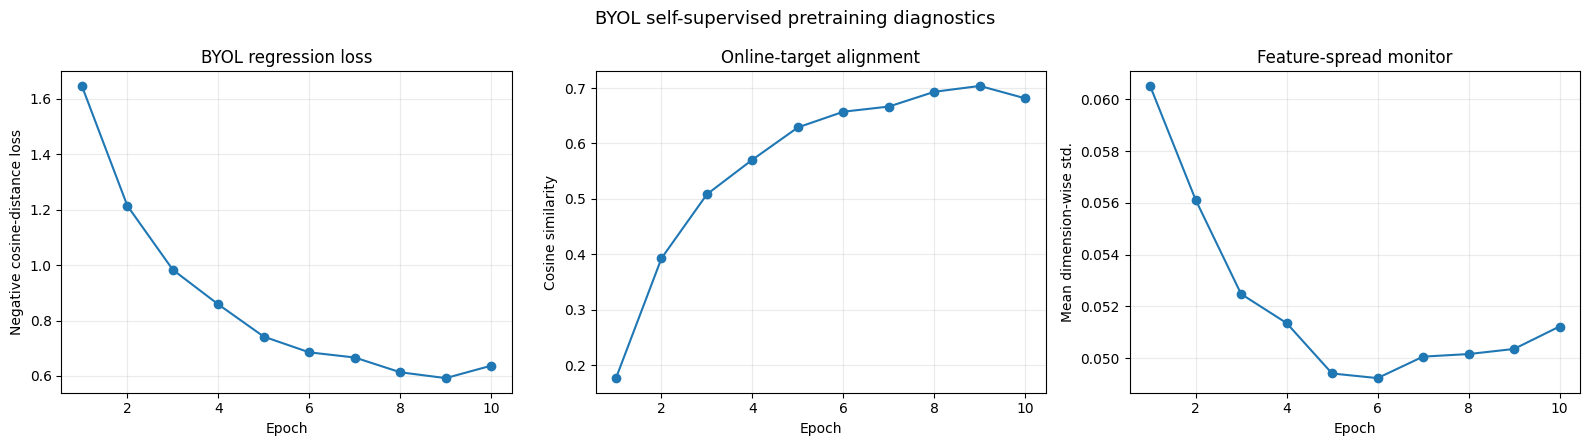

Interpretation: increasing online-target alignment indicates successful view prediction, while a non-zero feature-spread trace provides a basic warning signal against trivial collapse.


In [9]:

# ============================================================
# 9. BYOL learning curves and representation diagnostics
# ============================================================

figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(byol_history_df["epoch"], byol_history_df["byol_loss"], marker="o")
axes[0].set_title("BYOL regression loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Negative cosine-distance loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    byol_history_df["epoch"],
    byol_history_df["paired_cosine_similarity"],
    marker="o",
)
axes[1].set_title("Online-target alignment")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cosine similarity")
axes[1].grid(alpha=0.25)

axes[2].plot(
    byol_history_df["epoch"],
    byol_history_df["mean_feature_std"],
    marker="o",
)
axes[2].set_title("Feature-spread monitor")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Mean dimension-wise std.")
axes[2].grid(alpha=0.25)

figure.suptitle("BYOL self-supervised pretraining diagnostics", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "05_byol_training_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()

print(
    "Interpretation: increasing online-target alignment indicates successful view prediction, "
    "while a non-zero feature-spread trace provides a basic warning signal against trivial collapse."
)



## Direct transfer into DeepLabV3

BYOL learns its representation through the **online ResNet-50 encoder**. DeepLabV3-ResNet50 uses a compatible ResNet-50 feature extractor, allowing tensor-by-tensor transfer of the learned convolutional representation before supervised fine-tuning. The segmentation objective combines pixel-wise cross-entropy with foreground Dice loss to address the limited spatial occupancy of tumour pixels.


In [10]:

# ============================================================
# 10. Transfer BYOL encoder weights to DeepLabV3-ResNet50
# ============================================================

def build_deeplab_from_byol(trained_byol_model):
    """Transfer all shape-compatible online-encoder tensors into DeepLabV3's backbone."""
    segmentation_model = deeplabv3_resnet50(
        weights=None,
        weights_backbone=None,
        num_classes=NUM_CLASSES,
        aux_loss=True,
    )

    online_state = trained_byol_model.online_encoder.state_dict()
    backbone_state = segmentation_model.backbone.state_dict()

    transferable = {
        key: value.detach().cpu()
        for key, value in online_state.items()
        if key in backbone_state and backbone_state[key].shape == value.shape
    }

    missing_keys, unexpected_keys = segmentation_model.backbone.load_state_dict(
        transferable, strict=False
    )

    print(f"Transferred BYOL online-encoder tensors: {len(transferable)}")
    print(f"Remaining backbone entries not loaded from BYOL: {len(missing_keys)}")
    print(f"Unexpected transferred entries: {len(unexpected_keys)}")
    return segmentation_model

segmentation_model = build_deeplab_from_byol(byol_model).to(DEVICE)

class CrossEntropyForegroundDiceLoss(nn.Module):
    """Cross-entropy plus soft foreground Dice loss for binary segmentation."""
    def __init__(self, dice_weight=1.0, epsilon=1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.epsilon = epsilon

    def forward(self, logits, targets):
        cross_entropy = F.cross_entropy(logits, targets)

        tumour_probability = torch.softmax(logits.float(), dim=1)[:, 1]
        tumour_target = (targets == 1).float()

        intersection = (tumour_probability * tumour_target).sum(dim=(1, 2))
        denominator = tumour_probability.sum(dim=(1, 2)) + tumour_target.sum(dim=(1, 2))
        dice_score = (2.0 * intersection + self.epsilon) / (denominator + self.epsilon)
        dice_loss = 1.0 - dice_score.mean()

        return cross_entropy + self.dice_weight * dice_loss, cross_entropy.detach(), dice_loss.detach()

criterion = CrossEntropyForegroundDiceLoss(dice_weight=1.0)
segmentation_optimizer = torch.optim.AdamW(
    segmentation_model.parameters(), lr=SEGMENTATION_LR, weight_decay=WEIGHT_DECAY
)
segmentation_scaler = create_grad_scaler()

def confusion_counts(prediction, target):
    """Count tumour true positives, false positives, false negatives, and correct pixels."""
    prediction_foreground = prediction == 1
    target_foreground = target == 1

    true_positive = int((prediction_foreground & target_foreground).sum().item())
    false_positive = int((prediction_foreground & ~target_foreground).sum().item())
    false_negative = int((~prediction_foreground & target_foreground).sum().item())
    correct = int((prediction == target).sum().item())
    total = int(target.numel())
    return true_positive, false_positive, false_negative, correct, total

def calculate_metrics(tp, fp, fn, correct, total, epsilon=1e-7):
    return {
        "dice": (2.0 * tp + epsilon) / (2.0 * tp + fp + fn + epsilon),
        "iou": (tp + epsilon) / (tp + fp + fn + epsilon),
        "pixel_accuracy": correct / max(1, total),
    }

def run_segmentation_epoch(model, loader, optimizer=None, scaler=None, description="evaluation"):
    """Run one train or evaluation epoch for DeepLabV3."""
    training = optimizer is not None
    model.train(training)

    losses = []
    tp = fp = fn = correct = total = 0

    progress = tqdm(loader, desc=description, leave=False)
    for images, masks, _ in progress:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context():
                outputs = model(images)
                logits = F.interpolate(
                    outputs["out"], size=masks.shape[-2:],
                    mode="bilinear", align_corners=False
                )
                main_loss, _, _ = criterion(logits, masks)

                if training and "aux" in outputs:
                    aux_logits = F.interpolate(
                        outputs["aux"], size=masks.shape[-2:],
                        mode="bilinear", align_corners=False
                    )
                    aux_loss, _, _ = criterion(aux_logits, masks)
                    loss = main_loss + 0.4 * aux_loss
                else:
                    loss = main_loss

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        losses.append(float(loss.detach().cpu()))
        predictions = logits.detach().argmax(dim=1)
        batch_counts = confusion_counts(predictions, masks.detach())
        tp += batch_counts[0]
        fp += batch_counts[1]
        fn += batch_counts[2]
        correct += batch_counts[3]
        total += batch_counts[4]

        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    metrics = calculate_metrics(tp, fp, fn, correct, total)
    metrics["loss"] = float(np.mean(losses))
    return metrics


Transferred BYOL online-encoder tensors: 318
Remaining backbone entries not loaded from BYOL: 0
Unexpected transferred entries: 0


In [11]:

# ============================================================
# 11. Ten-epoch DeepLabV3 fine-tuning and held-out test evaluation
# ============================================================

segmentation_history = []
best_validation_dice = -1.0
best_checkpoint_path = CHECKPOINT_DIR / "best_byol_deeplabv3_binary_segmentation.pth"

for epoch in range(1, SEGMENTATION_EPOCHS + 1):
    train_metrics = run_segmentation_epoch(
        segmentation_model,
        train_loader,
        optimizer=segmentation_optimizer,
        scaler=segmentation_scaler,
        description=f"DeepLabV3 train {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )
    validation_metrics = run_segmentation_epoch(
        segmentation_model,
        valid_loader,
        description=f"DeepLabV3 valid {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )

    record = {"epoch": epoch}
    for name, value in train_metrics.items():
        record[f"train_{name}"] = value
    for name, value in validation_metrics.items():
        record[f"valid_{name}"] = value
    segmentation_history.append(record)

    print(
        f"Epoch {epoch:02d}: "
        f"train loss={train_metrics['loss']:.4f}, train Dice={train_metrics['dice']:.4f} | "
        f"valid loss={validation_metrics['loss']:.4f}, valid Dice={validation_metrics['dice']:.4f}, "
        f"valid IoU={validation_metrics['iou']:.4f}, "
        f"valid accuracy={validation_metrics['pixel_accuracy']:.4f}"
    )

    if validation_metrics["dice"] > best_validation_dice:
        best_validation_dice = validation_metrics["dice"]
        torch.save({
            "model_state_dict": segmentation_model.state_dict(),
            "epoch": epoch,
            "validation_metrics": validation_metrics,
            "source_encoder": "BYOL online ResNet-50 encoder",
        }, best_checkpoint_path)

segmentation_history_df = pd.DataFrame(segmentation_history)
segmentation_history_df.to_csv(METRIC_DIR / "deeplabv3_training_history.csv", index=False)

best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
segmentation_model.load_state_dict(best_checkpoint["model_state_dict"])

test_metrics = run_segmentation_epoch(
    segmentation_model, test_loader, description="Held-out test evaluation"
)
test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.to_csv(METRIC_DIR / "test_metrics.csv", index=False)

print("\nHeld-out test performance from the best validation checkpoint")
print(test_metrics_df.round(4).to_string(index=False))
print(f"\nBest checkpoint: {best_checkpoint_path}")


DeepLabV3 train 01/10:   0%|          | 0/251 [00:00<?, ?it/s]

DeepLabV3 valid 01/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 01: train loss=1.0986, train Dice=0.4339 | valid loss=0.6753, valid Dice=0.5077, valid IoU=0.3402, valid accuracy=0.9556


DeepLabV3 train 02/10:   0%|          | 0/251 [00:00<?, ?it/s]

DeepLabV3 valid 02/10:   0%|          | 0/72 [00:00<?, ?it/s]

...

DeepLabV3 train 10/10:   0%|          | 0/251 [00:00<?, ?it/s]

DeepLabV3 valid 10/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10: train loss=0.4866, train Dice=0.7360 | valid loss=0.4144, valid Dice=0.6827, valid IoU=0.5182, valid accuracy=0.9790


Held-out test evaluation:   0%|          | 0/36 [00:00<?, ?it/s]


Held-out test performance from the best validation checkpoint
 dice    iou  pixel_accuracy   loss
0.723 0.5661          0.9796 0.3673

Best checkpoint: /kaggle/working/byol_deeplabv3_brain_tumour/checkpoints/best_byol_deeplabv3_binary_segmentation.pth


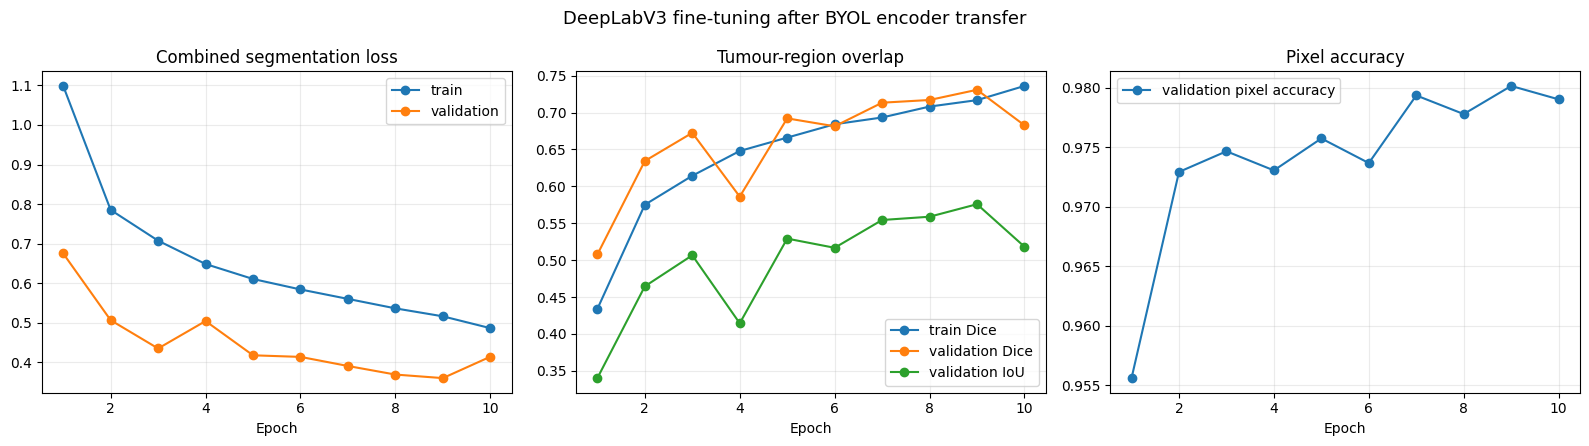

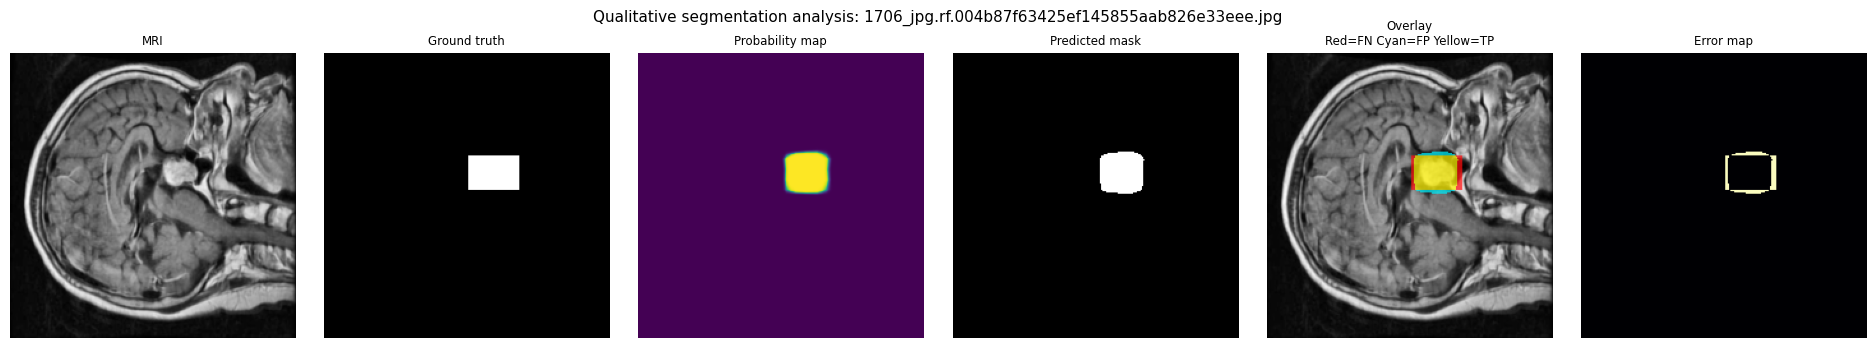

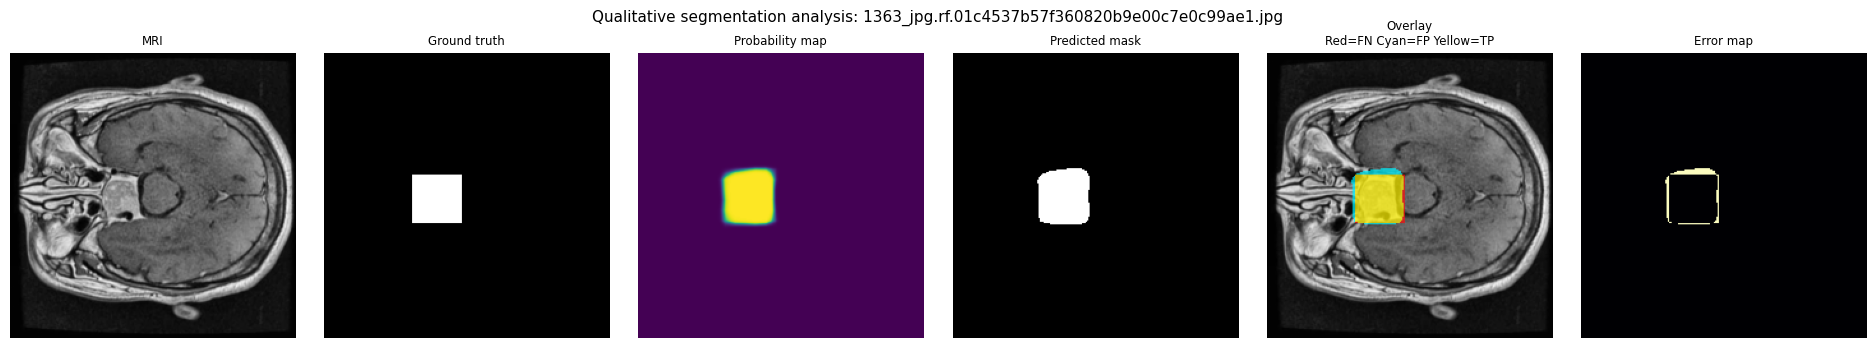

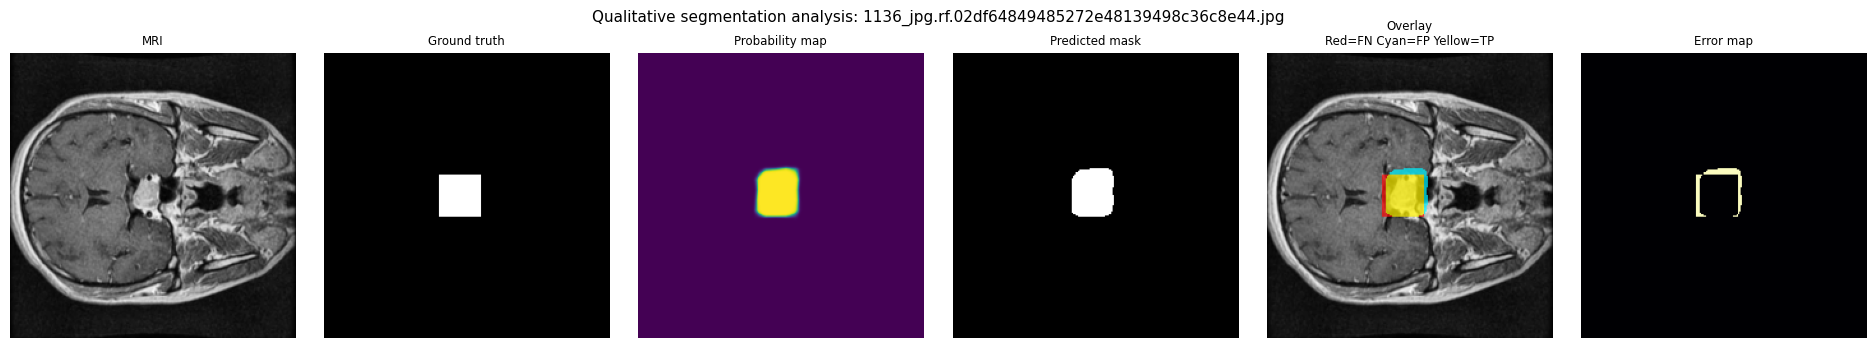

In [12]:

# ============================================================
# 12. Segmentation curves and qualitative prediction panels
# ============================================================

figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["train_loss"], marker="o", label="train")
axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_loss"], marker="o", label="validation")
axes[0].set_title("Combined segmentation loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["train_dice"], marker="o", label="train Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_dice"], marker="o", label="validation Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_iou"], marker="o", label="validation IoU")
axes[1].set_title("Tumour-region overlap")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(
    segmentation_history_df["epoch"], segmentation_history_df["valid_pixel_accuracy"],
    marker="o", label="validation pixel accuracy"
)
axes[2].set_title("Pixel accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.25)

figure.suptitle("DeepLabV3 fine-tuning after BYOL encoder transfer", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "06_segmentation_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

@torch.inference_mode()
def predict_one_sample(model, dataset, index):
    image, ground_truth, file_name = dataset[index]
    image_batch = image.unsqueeze(0).to(DEVICE).contiguous()

    with autocast_context():
        logits = model(image_batch)["out"]
        logits = F.interpolate(
            logits, size=ground_truth.shape[-2:],
            mode="bilinear", align_corners=False
        )

    probability = torch.softmax(logits.float(), dim=1)[0, 1].cpu()
    predicted_mask = (probability >= 0.5).long()
    return image, ground_truth, probability, predicted_mask, file_name

def make_comparison_overlay(image_array, ground_truth_array, predicted_array, alpha=0.72):
    """
    Overlay error categories on the MRI:
      yellow = correctly predicted tumour pixels;
      red    = missed tumour pixels;
      cyan   = falsely predicted tumour pixels.
    """
    overlay = image_array.copy()
    target = np.asarray(ground_truth_array).astype(bool)
    prediction = np.asarray(predicted_array).astype(bool)

    regions_and_colours = [
        (target & ~prediction, np.array([1.0, 0.05, 0.05], dtype=np.float32)),
        (~target & prediction, np.array([0.0, 0.95, 1.0], dtype=np.float32)),
        (target & prediction, np.array([1.0, 0.95, 0.0], dtype=np.float32)),
    ]

    for region, colour in regions_and_colours:
        if region.any():
            overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour

    return np.clip(overlay, 0.0, 1.0)

candidate_indices = [
    index for index in range(len(test_dataset))
    if test_dataset[index][1].sum().item() > 0
][:3]
if not candidate_indices:
    candidate_indices = list(range(min(3, len(test_dataset))))

for example_number, sample_index in enumerate(candidate_indices, start=1):
    image, ground_truth, probability, predicted_mask, file_name = predict_one_sample(
        segmentation_model, test_dataset, sample_index
    )

    display_image = undo_normalisation(image)
    ground_truth_array = ground_truth.numpy()
    probability_array = probability.numpy()
    predicted_array = predicted_mask.numpy()
    error_array = (predicted_mask != ground_truth).numpy().astype(np.float32)
    overlay = make_comparison_overlay(display_image, ground_truth_array, predicted_array)

    figure, axes = plt.subplots(1, 6, figsize=(19, 3.5))
    panels = [
        (display_image, "MRI", None),
        (ground_truth_array, "Ground truth", "gray"),
        (probability_array, "Probability map", "viridis"),
        (predicted_array, "Predicted mask", "gray"),
        (overlay, "Overlay\nRed=FN Cyan=FP Yellow=TP", None),
        (error_array, "Error map", "magma"),
    ]

    for axis, (panel, title, cmap) in zip(axes, panels):
        if cmap is None:
            axis.imshow(panel)
        else:
            axis.imshow(panel, cmap=cmap, vmin=0, vmax=1)
        axis.set_title(title, fontsize=8.5)
        axis.axis("off")

    figure.suptitle(f"Qualitative segmentation analysis: {file_name}", fontsize=11)
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / f"07_prediction_example_{example_number}.png", dpi=180, bbox_inches="tight")
    plt.show()



## Feature-space visualisation

The validation-set representations are compared at three stages:

1. **Initial encoder:** ResNet-50 parameters before BYOL updates.
2. **After BYOL:** the trained online encoder prior to segmentation supervision.
3. **After DeepLabV3 fine-tuning:** backbone features after learning pixel-level tumour boundaries.

The t-SNE colour indicates whether an MRI contains tumour pixels. The plot provides a qualitative account of neighbourhood structure; it is not a substitute for Dice or IoU evaluation.


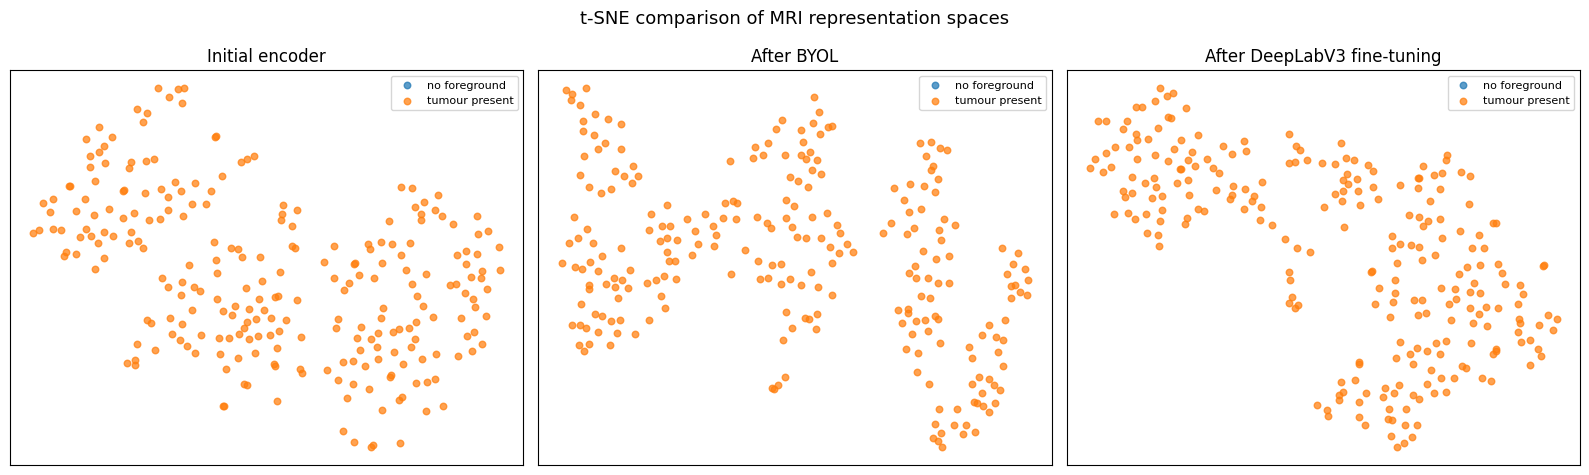

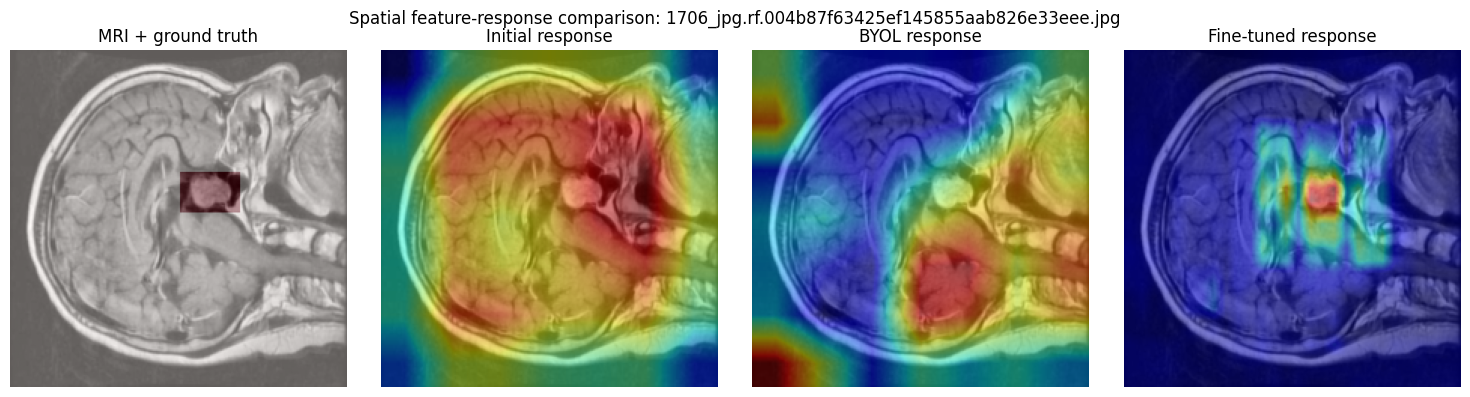

In [13]:

# ============================================================
# 13. Spatial response maps and t-SNE across the three stages
# ============================================================

def final_spatial_features(encoder, images):
    """Obtain the final ResNet convolutional feature map before global pooling."""
    x = encoder.conv1(images)
    x = encoder.bn1(x)
    x = encoder.relu(x)
    x = encoder.maxpool(x)
    x = encoder.layer1(x)
    x = encoder.layer2(x)
    x = encoder.layer3(x)
    return encoder.layer4(x)

initial_encoder = build_resnet_encoder(use_imagenet=False).to(DEVICE)
initial_encoder.load_state_dict(initial_encoder_state)
initial_encoder.eval()

byol_encoder = copy.deepcopy(byol_model.online_encoder).to(DEVICE)
byol_encoder.eval()

segmentation_model.eval()

@torch.inference_mode()
def collect_encoder_features(encoder, loader, maximum_samples=250):
    features, labels = [], []

    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        vectors = encoder(images).float().cpu().numpy()
        foreground_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()

        features.append(vectors)
        labels.append(foreground_present)

        if sum(len(part) for part in labels) >= maximum_samples:
            break

    return np.concatenate(features)[:maximum_samples], np.concatenate(labels)[:maximum_samples]

@torch.inference_mode()
def collect_deeplab_features(model, loader, maximum_samples=250):
    features, labels = [], []

    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        spatial_features = model.backbone(images)["out"]
        vectors = F.adaptive_avg_pool2d(spatial_features.float(), 1).flatten(1).cpu().numpy()
        foreground_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()

        features.append(vectors)
        labels.append(foreground_present)

        if sum(len(part) for part in labels) >= maximum_samples:
            break

    return np.concatenate(features)[:maximum_samples], np.concatenate(labels)[:maximum_samples]

initial_features, feature_labels = collect_encoder_features(initial_encoder, feature_loader)
byol_features, _ = collect_encoder_features(byol_encoder, feature_loader)
fine_tuned_features, _ = collect_deeplab_features(segmentation_model, feature_loader)

def compute_tsne(features):
    scaled_features = StandardScaler().fit_transform(features)
    sample_count = scaled_features.shape[0]
    perplexity = max(2, min(30, sample_count // 4, sample_count - 1))
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(scaled_features)

embedded_features = [
    compute_tsne(initial_features),
    compute_tsne(byol_features),
    compute_tsne(fine_tuned_features),
]
plot_titles = [
    "Initial encoder",
    "After BYOL",
    "After DeepLabV3 fine-tuning",
]

figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, embedding, title in zip(axes, embedded_features, plot_titles):
    for class_value, label_name in [(0, "no foreground"), (1, "tumour present")]:
        selected = feature_labels == class_value
        axis.scatter(embedding[selected, 0], embedding[selected, 1], s=22, alpha=0.72, label=label_name)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.legend(fontsize=8)

figure.suptitle("t-SNE comparison of MRI representation spaces", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "08_tsne_three_stages.png", dpi=180, bbox_inches="tight")
plt.show()

response_index = candidate_indices[0] if candidate_indices else 0
response_image, response_mask, response_name = test_dataset[response_index]
response_batch = response_image.unsqueeze(0).to(DEVICE).contiguous()

@torch.inference_mode()
def normalised_response_map(feature_map, output_size):
    response = feature_map.float().abs().mean(dim=1, keepdim=True)
    response = F.interpolate(response, size=output_size, mode="bilinear", align_corners=False)[0, 0]
    response = response - response.min()
    response = response / (response.max() + 1e-7)
    return response.cpu().numpy()

initial_map = normalised_response_map(
    final_spatial_features(initial_encoder, response_batch), response_mask.shape[-2:]
)
byol_map = normalised_response_map(
    final_spatial_features(byol_encoder, response_batch), response_mask.shape[-2:]
)
fine_tuned_map = normalised_response_map(
    segmentation_model.backbone(response_batch)["out"], response_mask.shape[-2:]
)

base_image = undo_normalisation(response_image)
figure, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(base_image)
axes[0].imshow(response_mask.numpy(), cmap="Reds", alpha=0.38, vmin=0, vmax=1)
axes[0].set_title("MRI + ground truth")

for axis, response, title in zip(
    axes[1:],
    [initial_map, byol_map, fine_tuned_map],
    ["Initial response", "BYOL response", "Fine-tuned response"],
):
    axis.imshow(base_image)
    axis.imshow(response, cmap="jet", alpha=0.48, vmin=0, vmax=1)
    axis.set_title(title)

for axis in axes:
    axis.axis("off")

figure.suptitle(f"Spatial feature-response comparison: {response_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "09_spatial_response_three_stages.png", dpi=180, bbox_inches="tight")
plt.show()


In [14]:

# ============================================================
# 14. Export experiment summary
# ============================================================

experiment_summary = {
    "course": "CSE 438: Digital Image Processing",
    "instructor": "Dr Md Rifat Ahmmad Rashid",
    "pipeline": "BYOL ResNet-50 online encoder transferred to DeepLabV3-ResNet50",
    "dataset_root": str(DATA_ROOT),
    "classes": {"0": "background", "1": "tumour region"},
    "device": str(DEVICE),
    "amp_enabled": bool(AMP_ENABLED),
    "byol_epochs": BYOL_EPOCHS,
    "segmentation_epochs": SEGMENTATION_EPOCHS,
    "byol_configuration": {
        "projection_dim": PROJECTION_DIM,
        "ema_base_momentum": EMA_BASE_MOMENTUM,
    },
    "best_validation_dice": float(best_validation_dice),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "saved_outputs": {
        "figures": str(FIGURE_DIR),
        "checkpoints": str(CHECKPOINT_DIR),
        "metrics": str(METRIC_DIR),
    },
}

with open(OUTPUT_DIR / "experiment_summary.json", "w", encoding="utf-8") as file:
    json.dump(experiment_summary, file, indent=2)

print(json.dumps(experiment_summary, indent=2))
print("\nSummary comment:")
print(
    "BYOL trains an MRI representation without negative examples; DeepLabV3 then "
    "uses the directly transferred online encoder for pixel-level tumour segmentation. "
    "The outcome should be interpreted through overlap metrics, visible overlay errors, "
    "spatial responses, and feature-space changes."
)


{
  "course": "CSE 438: Digital Image Processing",
  "instructor": "Dr Md Rifat Ahmmad Rashid",
  "pipeline": "BYOL ResNet-50 online encoder transferred to DeepLabV3-ResNet50",
  "dataset_root": "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation",
  "classes": {
    "0": "background",
    "1": "tumour region"
  },
  "device": "cuda",
  "amp_enabled": true,
  "byol_epochs": 10,
  "segmentation_epochs": 10,
  "byol_configuration": {
    "projection_dim": 256,
    "ema_base_momentum": 0.996
  },
  "best_validation_dice": 0.7308075898231662,
  "test_metrics": {
    "dice": 0.7229780877499669,
    "iou": 0.5661438388916751,
    "pixel_accuracy": 0.9796463425486474,
    "loss": 0.36726658460166717
  },
  "saved_outputs": {
    "figures": "/kaggle/working/byol_deeplabv3_brain_tumour/figures",
    "checkpoints": "/kaggle/working/byol_deeplabv3_brain_tumour/checkpoints",
    "metrics": "/kaggle/working/byol_deeplabv3_brain_tumour/metrics"
  }
}

Summary comment:
BY


## References

1. Grill, J.-B., Strub, F., Altché, F., et al. (2020). *Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning*. Advances in Neural Information Processing Systems, 33, 21271–21284.  
2. Chen, L.-C., Papandreou, G., Schroff, F., and Adam, H. (2017). *Rethinking Atrous Convolution for Semantic Image Segmentation*. arXiv:1706.05587.  
3. He, K., Zhang, X., Ren, S., and Sun, J. (2016). *Deep Residual Learning for Image Recognition*. Proceedings of CVPR, 770–778.
